> **Notebook 2 of 4 - EDA & Business Insights**  
> Input: `data/sales_clean.csv` · Next: `03_rfm.ipynb`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [2]:
sales_df = pd.read_csv('../data/sales_clean.csv', parse_dates=['InvoiceDate'],
                       dtype={'InvoiceNo': str, 'StockCode': str})
sales_df.shape

(534129, 14)

# 6. Exploratory Data Analysis

The EDA follows the business questions: sales, products, customers, time, geography, baskets, and returns.

### 6.1 Sales overview

In [3]:
gross_sales = sales_df.loc[sales_df['Quantity'] > 0, 'TotalLineRevenue'].sum()
return_value = sales_df.loc[sales_df['Quantity'] < 0, 'TotalLineRevenue'].sum()
net_revenue = sales_df['TotalLineRevenue'].sum()

print("Total orders (invoices):", sales_df['InvoiceNo'].nunique())
print("Gross sales  : %.0f" % gross_sales)
print("Return value : %.0f" % return_value)
print("Net revenue  : %.0f" % net_revenue)
print("Return value as %% of gross sales: %.1f%%" % (abs(return_value) / gross_sales * 100))
print("Sales lines:", (sales_df['Quantity'] > 0).sum(), "| Return lines:", (sales_df['Quantity'] < 0).sum())

guest = sales_df['CustomerID'].isna()
print("Guest lines (no CustomerID): %.1f%% of lines, %.1f%% of net revenue" % (
    guest.mean() * 100, sales_df.loc[guest, 'TotalLineRevenue'].sum() / net_revenue * 100))

Total orders (invoices): 23796
Gross sales  : 10642111
Return value : -893980
Net revenue  : 9748131
Return value as % of gross sales: 8.4%
Sales lines: 524878 | Return lines: 9251
Guest lines (no CustomerID): 24.8% of lines, 15.1% of net revenue


Gross sales are **£10.64M**, returns remove **£0.89M** (8.4% of gross sales), leaving **£9.75M** net revenue across 23,796 invoices. The 9,251 return lines and 524,878 sales lines are *lines*, not orders, so they are not order-level return rates.

Guest invoices (no `CustomerID`) are 24.8% of lines but **15.1% of net revenue**, so excluding them from customer analysis leaves out a meaningful part of the business.

### 6.2 Products

In [4]:
# Product-level analysis uses real products only (5-digit stock codes).
# Codes such as POST, DOT, M, AMAZONFEE, BANK CHARGES are services/fees.
product_lines = sales_df[sales_df['StockCode'].astype(str).str.match(r'^\d{5}')]
product_desc = product_lines.groupby('StockCode')['Description'].agg(lambda x: x.mode()[0])

product_summary = (
    product_lines[product_lines['Quantity'] > 0]
    .groupby('StockCode')
    .agg(UnitsSold=('Quantity', 'sum'),
         Revenue=('TotalLineRevenue', 'sum'),
         Orders=('InvoiceNo', 'nunique'))
    .join(product_desc)
)

print("Top 10 products by revenue")
display(product_summary.sort_values('Revenue', ascending=False).head(10))
print("Top 10 products by units sold")
display(product_summary.sort_values('UnitsSold', ascending=False).head(10))

Top 10 products by revenue


,UnitsSold,Revenue,Orders,Description
StockCode,,,,
22423,13851,174156.54,1988,REGENCY CAKESTAND 3 TIER
23843,80995,168469.60,1,"PAPER CRAFT , LITTLE BIRDIE"
85123A,37641,104462.75,2198,WHITE HANGING HEART T-LIGHT HOLDER
47566,18283,99445.23,1685,PARTY BUNTING
85099B,48371,94159.81,2089,JUMBO BAG RED RETROSPOT
23166,78033,81700.92,247,MEDIUM CERAMIC TOP STORAGE JAR
23084,30739,66870.03,994,RABBIT NIGHT LIGHT
22086,19329,64875.59,1160,PAPER CHAIN KIT 50'S CHRISTMAS
84879,36362,58927.62,1455,ASSORTED COLOUR BIRD ORNAMENT


Top 10 products by units sold


,UnitsSold,Revenue,Orders,Description
StockCode,,,,
23843,80995,168469.60,1,"PAPER CRAFT , LITTLE BIRDIE"
23166,78033,81700.92,247,MEDIUM CERAMIC TOP STORAGE JAR
22197,56898,51334.47,1392,POPCORN HOLDER
84077,54951,13814.01,535,WORLD WAR 2 GLIDERS ASSTD DESIGNS
85099B,48371,94159.81,2089,JUMBO BAG RED RETROSPOT
85123A,37641,104462.75,2198,WHITE HANGING HEART T-LIGHT HOLDER
21212,36396,21246.45,1320,PACK OF 72 RETROSPOT CAKE CASES
84879,36362,58927.62,1455,ASSORTED COLOUR BIRD ORNAMENT
23084,30739,66870.03,994,RABBIT NIGHT LIGHT


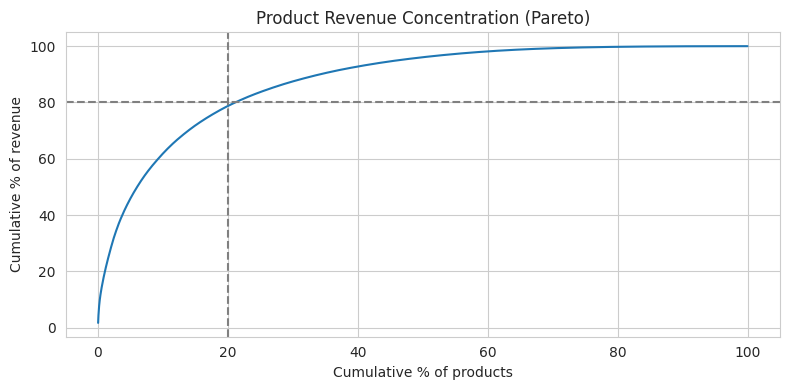

Top 20% of products generate 78.8% of product revenue


In [5]:
# Pareto: cumulative share of revenue by product
pareto = product_summary.sort_values('Revenue', ascending=False).copy()
pareto['CumRevenuePct'] = pareto['Revenue'].cumsum() / pareto['Revenue'].sum() * 100
pareto['ProductPct'] = np.arange(1, len(pareto) + 1) / len(pareto) * 100

plt.figure(figsize=(8, 4))
plt.plot(pareto['ProductPct'], pareto['CumRevenuePct'])
plt.axhline(80, linestyle='--', color='gray')
plt.axvline(20, linestyle='--', color='gray')
plt.xlabel('Cumulative % of products')
plt.ylabel('Cumulative % of revenue')
plt.title('Product Revenue Concentration (Pareto)')
plt.tight_layout()
plt.show()

share_top20 = pareto.loc[pareto['ProductPct'] <= 20, 'CumRevenuePct'].max()
print("Top 20%% of products generate %.1f%% of product revenue" % share_top20)

Product rankings use real products only (5-digit codes); fee and service codes such as `POST`, `DOT`, `M` and `AMAZONFEE` are excluded.

- **Top revenue:** Regency Cakestand 3 Tier (£174k), White Hanging Heart T-Light Holder (£104k), Party Bunting (£99k), Jumbo Bag Red Retrospot (£94k).
- **Top units:** cheap, high-volume items such as Medium Ceramic Top Storage Jar (78k units) and Popcorn Holder (57k units) sell many units but earn less revenue per unit.
- `PAPER CRAFT, LITTLE BIRDIE` ranks high in both lists only because of one 80,995-unit order that was cancelled 12 minutes later.
- **Pareto:** the top 20% of products generate about **79%** of product revenue, close to the 80/20 rule.

In [6]:
# Dead stock: good historical sellers with zero or negative net sales in the last 90 days
cutoff = product_lines['InvoiceDate'].max() - pd.Timedelta(days=90)

hist_units = product_lines[product_lines['InvoiceDate'] <= cutoff].groupby('StockCode')['Quantity'].sum()
last90_units = product_lines[product_lines['InvoiceDate'] > cutoff].groupby('StockCode')['Quantity'].sum()

stock = pd.DataFrame({'HistoricalUnits': hist_units}).join(last90_units.rename('Last90Units'))
stock['Last90Units'] = stock['Last90Units'].fillna(0)
stock = stock.join(product_desc)

high_volume = stock['HistoricalUnits'] >= stock['HistoricalUnits'].quantile(0.75)
dead_stock = stock[high_volume & (stock['Last90Units'] <= 0)].sort_values('HistoricalUnits', ascending=False)

print("High-volume products:", high_volume.sum(), "| Dead stock among them:", len(dead_stock))
dead_stock.head(10)

High-volume products: 918 | Dead stock among them: 22


,HistoricalUnits,Last90Units,Description
StockCode,,,
18007,5884,0.0,ESSENTIAL BALM 3.5g TIN IN ENVELOPE
10133,2846,0.0,COLOURING PENCILS BROWN TUBE
22855,2630,0.0,FINE WICKER HEART
47556B,2600,0.0,TEA TIME TEA TOWELS
17096,2545,0.0,ASSORTED LAQUERED INCENSE HOLDERS
21399,1943,0.0,BLUE POLKADOT COFFEE MUG
21033,1931,0.0,JUMBO BAG CHARLIE AND LOLA TOYS
22088,1837,0.0,PAPER BUNTING COLOURED LACE
21398,1532,0.0,RED POLKADOT COFFEE MUG


**Dead stock:** 22 of the 918 high-volume products (top quartile of historical units) had zero or negative net sales in the last 90 days, for example Essential Balm tins (5,884 historical units) and Colouring Pencils. These are candidates for clearance or a discontinuation review; some may simply be seasonal.

### 6.3 Customers

In [7]:
customer_summary = (
    sales_df[sales_df['CustomerID'].notna()]
    .groupby('CustomerID')
    .agg(Revenue=('TotalLineRevenue', 'sum'),
         Orders=('InvoiceNo', 'nunique'),
         Quantity=('Quantity', 'sum'))
    .sort_values('Revenue', ascending=False)
)

display(customer_summary.head(10))

top10pct = customer_summary.head(int(len(customer_summary) * 0.10))
print("Top 10%% of customers generate %.1f%% of customer net revenue" % (top10pct['Revenue'].sum() / customer_summary['Revenue'].sum() * 100))

,Revenue,Orders,Quantity
CustomerID,,,
14646.0,279489.02,76,196143
18102.0,256438.49,62,64122
17450.0,187322.17,55,69009
14911.0,132458.73,248,76905
12415.0,123725.45,26,76946
14156.0,113214.59,66,56908
17511.0,88125.38,46,63012
16684.0,65892.08,31,49390
13694.0,62690.54,60,61899


Top 10% of customers generate 60.1% of customer net revenue


Customer 14646 is the top spender (£279k, 76 orders), followed by 18102 (£256k) and 17450 (£187k). Customer 14911 places the most orders (248) but ranks fourth in revenue, so order count and revenue rank customers differently. The **top 10% of customers generate 60.1%** of customer net revenue.

### 6.4 Time patterns

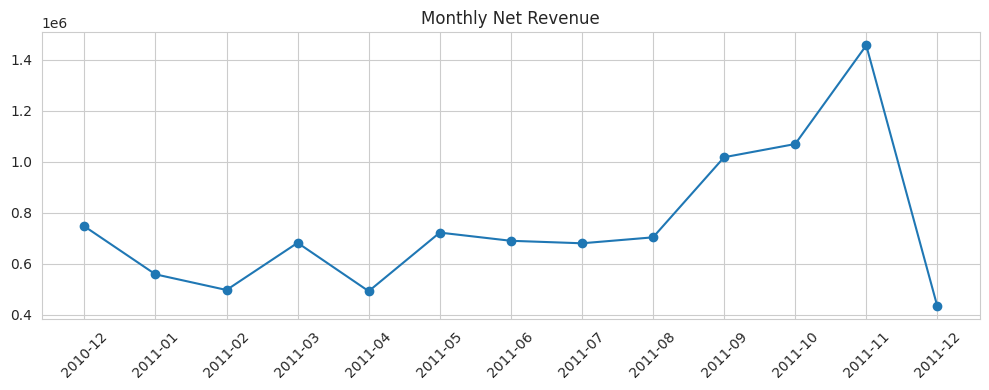

,Period,TotalLineRevenue
0,2010-12,746724.0
1,2011-01,558449.0
2,2011-02,497026.0
3,2011-03,682014.0
4,2011-04,492368.0
5,2011-05,722094.0
6,2011-06,689977.0
7,2011-07,680157.0
8,2011-08,703511.0
9,2011-09,1017597.0


In [8]:
monthly_revenue = sales_df.groupby(['Year', 'Month'])['TotalLineRevenue'].sum().reset_index()
monthly_revenue['Period'] = monthly_revenue['Year'].astype(str) + '-' + monthly_revenue['Month'].astype(str).str.zfill(2)

plt.figure(figsize=(10, 4))
plt.plot(monthly_revenue['Period'], monthly_revenue['TotalLineRevenue'], marker='o')
plt.title('Monthly Net Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

monthly_revenue[['Period', 'TotalLineRevenue']].round(0)

Monthly revenue stays around £0.5M–£0.75M from December to August, then rises to **£1.02M in September, £1.07M in October and a peak of £1.46M in November**. December 2011 is incomplete (data ends on 9 Dec), so its drop is not a real decline. Only one year is available, so the Q4 surge suggests seasonality but cannot prove it repeats.

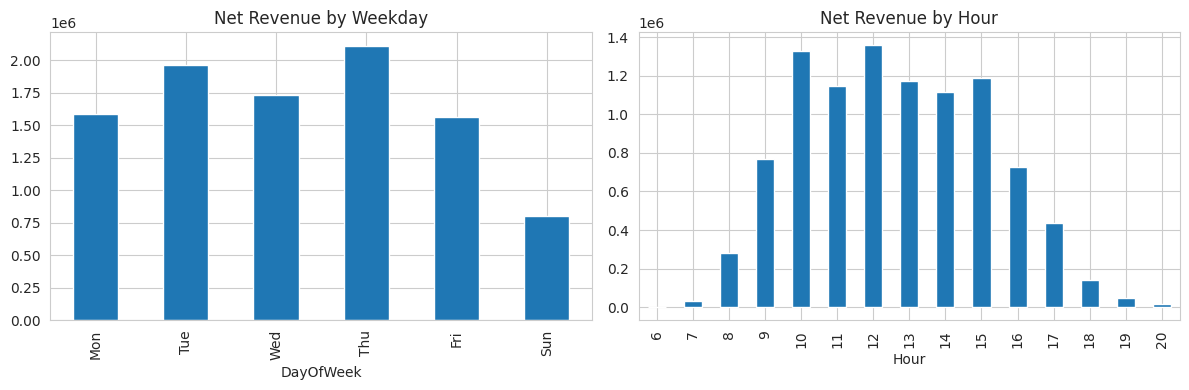

DayOfWeek
Mon    1584895.0
Tue    1965704.0
Wed    1730088.0
Thu    2108702.0
Fri    1560083.0
Sun     798659.0
Name: TotalLineRevenue, dtype: float64
Hour
12    1357595.0
10    1327330.0
15    1186819.0
13    1172986.0
11    1146457.0
Name: TotalLineRevenue, dtype: float64


In [9]:
day_names = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}

weekday_revenue = sales_df.groupby('DayOfWeek')['TotalLineRevenue'].sum()
weekday_revenue.index = weekday_revenue.index.map(day_names)

hourly_revenue = sales_df.groupby('Hour')['TotalLineRevenue'].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
weekday_revenue.plot(kind='bar', ax=axes[0], title='Net Revenue by Weekday')
hourly_revenue.plot(kind='bar', ax=axes[1], title='Net Revenue by Hour')
plt.tight_layout()
plt.show()

print(weekday_revenue.round(0))
print(hourly_revenue.nlargest(5).round(0))

**Weekdays:** Thursday is strongest (£2.11M), then Tuesday (£1.97M); Sunday is weakest (£0.80M). There are no Saturday transactions in the data.

**Hours:** activity is concentrated between 10:00 and 15:00, with the peak at 12:00 (£1.36M) and 10:00 (£1.33M). Maintenance is safest early morning or evening, and campaigns fit late morning.

### 6.5 Geography

In [10]:
country_summary = (
    sales_df.groupby('Country')
    .agg(Customers=('CustomerID', 'nunique'),
         Orders=('InvoiceNo', 'nunique'),
         Revenue=('TotalLineRevenue', 'sum'))
    .sort_values('Revenue', ascending=False)
)
country_summary['RevenueShare%'] = (country_summary['Revenue'] / country_summary['Revenue'].sum() * 100).round(1)
country_summary.head(10)

,Customers,Orders,Revenue,RevenueShare%
Country,,,,
United Kingdom,3949,21391,8189252.304,84.0
Netherlands,9,100,284661.540,2.9
EIRE,3,360,262993.380,2.7
Germany,95,603,221509.470,2.3
France,87,461,197317.110,2.0
Australia,9,69,137009.770,1.4
Switzerland,21,74,56363.050,0.6
Spain,31,105,54756.030,0.6
Belgium,25,119,40910.960,0.4


In [11]:
# UK vs international order behaviour (positive orders only)
orders = (
    sales_df[sales_df['Quantity'] > 0]
    .groupby('InvoiceNo')
    .agg(Value=('TotalLineRevenue', 'sum'), Items=('Quantity', 'sum'), Is_UK=('Is_UK', 'first'))
)
orders.groupby('Is_UK')[['Value', 'Items']].agg(['count', 'mean', 'median']).round(0)

Value                Items              
       count   mean median  count   mean median
Is_UK                                          
0       1941  845.0  424.0   1941  477.0  216.0
1      18019  500.0  300.0  18019  258.0  145.0

The UK generates **84%** of revenue and has 3,949 of the 4,371 customers. Netherlands (2.9%), EIRE (2.7%), Germany (2.3%) and France (2.0%) follow. Netherlands, EIRE and Australia earn large revenue from only 9, 3 and 9 customers, which points to a few large accounts, while Germany and France have broader customer bases (95 and 87).

International orders are larger than UK orders: average order value £845 vs £500 and median 216 vs 145 items per order.

### 6.6 Baskets and order value

In [12]:
basket_summary = (
    sales_df[sales_df['Quantity'] > 0]
    .groupby('InvoiceNo')
    .agg(BasketSize=('Quantity', 'sum'),
         BasketValue=('TotalLineRevenue', 'sum'),
         UniqueProducts=('StockCode', 'nunique'))
)

print("Gross AOV: %.0f" % basket_summary['BasketValue'].mean())
print("Net AOV  : %.0f" % sales_df.groupby('InvoiceNo')['TotalLineRevenue'].sum().mean())
basket_summary.describe(percentiles=[0.5, 0.9, 0.99]).round(0)

Gross AOV: 533
Net AOV  : 410


,BasketSize,BasketValue,UniqueProducts
count,19960.0,19960.0,19960.0
mean,279.0,533.0,26.0
std,955.0,1780.0,47.0
min,1.0,0.0,1.0
50%,150.0,303.0,15.0
90%,528.0,938.0,52.0
99%,2233.0,4821.0,217.0
max,80995.0,168470.0,1110.0


In [13]:
sizes = basket_summary['BasketSize']
print("Baskets > 500 items :", (sizes > 500).sum())
print("Baskets > 1000 items:", (sizes > 1000).sum())
print("Baskets > 5000 items:", (sizes > 5000).sum())

basket_summary.sort_values('BasketSize', ascending=False).head(5)

Baskets > 500 items : 2189
Baskets > 1000 items: 715
Baskets > 5000 items: 48


,BasketSize,BasketValue,UniqueProducts
InvoiceNo,,,
581483,80995,168469.60,1
541431,74215,77183.60,1
556917,15049,22775.93,138
563076,14730,19150.66,119
574941,14149,52940.94,101


In [14]:
# The two largest baskets: what happened to them?
sales_df[sales_df['CustomerID'].isin([12346, 16446])][
    ['InvoiceNo', 'InvoiceDate', 'StockCode', 'Quantity', 'UnitPrice', 'CustomerID']
]

,InvoiceNo,InvoiceDate,StockCode,Quantity,UnitPrice,CustomerID
60678,541431,2011-01-18 10:01:00,23166,74215,1.04,12346.0
60683,C541433,2011-01-18 10:17:00,23166,-74215,1.04,12346.0
191505,553573,2011-05-18 09:52:00,22980,1,1.65,16446.0
191506,553573,2011-05-18 09:52:00,22982,1,1.25,16446.0
532648,581483,2011-12-09 09:15:00,23843,80995,2.08,16446.0
532649,C581484,2011-12-09 09:27:00,23843,-80995,2.08,16446.0


Gross AOV is **£533** and net AOV is **£410**, so returns lower the value of an average invoice by about 23%. The median basket has 150 items (£303) but the mean is 279, showing a right-skewed distribution: 715 baskets exceed 1,000 items and 48 exceed 5,000, which is clear evidence of **bulk/wholesale buying**.

The two largest baskets (74,215 units by customer 12346 and 80,995 units by customer 16446) were each cancelled 12–16 minutes later, so they are **not** real bulk demand and must not be used as evidence of wholesale behavior.

### 6.7 Returns and cancellations

In [15]:
returns = product_lines[product_lines['Quantity'] < 0]

return_products = (
    returns.groupby('StockCode')
    .agg(ReturnedUnits=('Quantity', lambda x: -x.sum()),
         ReturnValue=('TotalLineRevenue', lambda x: -x.sum()),
         ReturnInvoices=('InvoiceNo', 'nunique'))
    .join(product_desc)
    .sort_values('ReturnInvoices', ascending=False)
)
return_products.head(8)

,ReturnedUnits,ReturnValue,ReturnInvoices,Description
StockCode,,,,
22423,855,9697.05,180,REGENCY CAKESTAND 3 TIER
22960,247,1012.79,87,JAM MAKING SET WITH JARS
22720,154,730.10,73,SET OF 3 CAKE TINS PANTRY DESIGN
21232,384,442.00,57,STRAWBERRY CERAMIC TRINKET BOX
22699,437,1150.35,54,ROSES REGENCY TEACUP AND SAUCER
22197,471,366.55,50,POPCORN HOLDER
22666,151,421.05,47,RECIPE BOX PANTRY YELLOW DESIGN
20725,574,854.70,43,LUNCH BAG RED RETROSPOT


In [16]:
return_customers = (
    sales_df[(sales_df['CustomerID'].notna()) & (sales_df['Quantity'] < 0)]
    .groupby('CustomerID')
    .agg(ReturnedUnits=('Quantity', lambda x: -x.sum()),
         ReturnValue=('TotalLineRevenue', lambda x: -x.sum()),
         ReturnInvoices=('InvoiceNo', 'nunique'))
    .sort_values('ReturnValue', ascending=False)
)

print("Customers with at least one return:", len(return_customers))
return_customers.head(8).round(0)

Customers with at least one return: 1589


,ReturnedUnits,ReturnValue,ReturnInvoices
CustomerID,,,
16446.0,80995,168470.0,1
12346.0,74215,77184.0,1
15098.0,61,39267.0,2
16029.0,6476,27682.0,13
15749.0,9014,22998.0,1
12744.0,7,12159.0,3
14911.0,3335,11252.0,47
12931.0,4627,8593.0,5


1,589 customers (36% of all customers) have at least one return line. Returns are frequent for popular products: Regency Cakestand has the most return invoices (180), which mirrors its high sales. Customers 16446 and 12346 have the largest return values only because of the cancelled mega-orders above, while customer 14911 has 47 return invoices next to 248 orders, a genuinely frequent buyer and returner. These are descriptive patterns and do not show that a product is defective.

# 7. Business Insights

1. **Products:** revenue is concentrated: the top 20% of products generate about 79% of product revenue, led by Regency Cakestand and White Hanging Heart T-Light Holder. High-unit items are usually low-priced.
2. **Customers:** the top 10% of customers generate 60.1% of net customer revenue, so a small group needs to be protected.
3. **Trend:** revenue is stable through summer and jumps in Sept–Nov (peak £1.46M in November). December is incomplete and cannot be compared.
4. **Timing:** Thursday and Tuesday are the strongest days, Sunday the weakest, and 10:00–15:00 is the busiest window.
5. **Geography:** the UK gives 84% of revenue; Netherlands, EIRE, Germany and France lead the rest.
6. **Seasonality:** the Sept–Nov increase suggests a pre-Christmas pattern, but one year of data cannot confirm it.
7. **Returns:** returns cost £0.89M (8.4% of gross sales) and 36% of customers have at least one return line.
8. **Typical customer:** the median customer has 3 orders, 364 items, £644 revenue and £235 AOV; the means (5.1 orders, £1,894) are much higher, so behavior is right-skewed.
9. **Wholesale behavior:** 715 baskets exceed 1,000 items, so bulk buying exists, but the two largest baskets were cancelled and are excluded from this conclusion.
10. **Segmentation:** value is very unequal across customers, which justifies RFM and clustering (sections 9–13).
11. **International buyers:** international orders are about 1.7× the UK average value (£845 vs £500).
12. **Dead stock:** 22 previously high-volume products had no net sales in the last 90 days.
13. **Guest checkout:** guest invoices are 15.1% of net revenue, so customer-level analysis covers about 85% of revenue.